# Outlier Detection — Statistical Abnormal Value Scan
### Detectron AI · Module 15

A focused, classical-statistics companion to the Anomaly Detection module. This notebook
applies **Tukey's IQR fences** and **modified Z-score (MAD-based)** — the two most widely
used robust outlier detection methods in exploratory data analysis — to a real-world-style
dataset, and visualizes results with a box plot.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(3)


## 1. Dataset — exam scores with a few data-entry errors

In [2]:
scores = np.random.normal(68, 9, 60).round(1)
# inject obvious data errors / true outliers
scores = np.append(scores, [2.0, 145.0, -5.0, 99.9])
df = pd.DataFrame({"score": scores})
df.describe()


,score
count,64.000000
mean,65.598438
std,18.659714
min,-5.000000
25%,58.800000
50%,65.150000
75%,74.925000
max,145.000000


## 2. IQR (Tukey fences) method

In [3]:
q1, q3 = df["score"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

df["iqr_outlier"] = (df["score"] < lower_fence) | (df["score"] > upper_fence)
print(f"Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}")
print(f"Fences: [{lower_fence:.2f}, {upper_fence:.2f}]")
print(f"IQR-flagged outliers: {df['iqr_outlier'].sum()}")
df[df["iqr_outlier"]]


Q1=58.80  Q3=74.92  IQR=16.12
Fences: [34.61, 99.11]
IQR-flagged outliers: 4


,score,iqr_outlier
60,2.0,True
61,145.0,True
62,-5.0,True
63,99.9,True


## 3. Modified Z-score (median absolute deviation)

More robust than the standard z-score because it doesn't use the mean/std (which outliers themselves distort).

In [4]:
median = df["score"].median()
mad = np.median(np.abs(df["score"] - median))
df["modified_z"] = 0.6745 * (df["score"] - median) / mad
df["mad_outlier"] = df["modified_z"].abs() > 3.5

print(f"Median={median:.2f}  MAD={mad:.2f}")
print(f"MAD-flagged outliers: {df['mad_outlier'].sum()}")
df[df["mad_outlier"]]


Median=65.15  MAD=7.55
MAD-flagged outliers: 3


,score,iqr_outlier,modified_z,mad_outlier
60,2.0,True,-5.641679,True
61,145.0,True,7.133619,True
62,-5.0,True,-6.267043,True


## 4. Visualize with a box plot

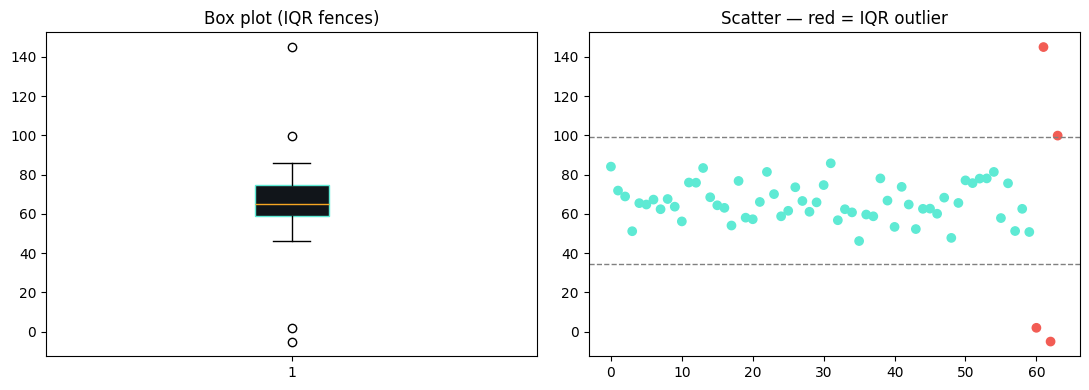

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))

ax[0].boxplot(df["score"], vert=True, patch_artist=True,
              boxprops=dict(facecolor="#11151A", color="#5EEAD4"),
              medianprops=dict(color="#F5A623"))
ax[0].set_title("Box plot (IQR fences)")

ax[1].scatter(range(len(df)), df["score"],
              c=np.where(df["iqr_outlier"], "#F25C54", "#5EEAD4"))
ax[1].axhline(upper_fence, linestyle="--", color="gray", linewidth=1)
ax[1].axhline(lower_fence, linestyle="--", color="gray", linewidth=1)
ax[1].set_title("Scatter — red = IQR outlier")

plt.tight_layout()
plt.show()


## 5. Method agreement

In [6]:
agreement = df[df["iqr_outlier"] & df["mad_outlier"]]
print(f"Points flagged by BOTH methods: {len(agreement)}")
agreement


Points flagged by BOTH methods: 3


,score,iqr_outlier,modified_z,mad_outlier
60,2.0,True,-5.641679,True
61,145.0,True,7.133619,True
62,-5.0,True,-6.267043,True


## Notes

- IQR fences are simple and interpretable but can under-flag in skewed distributions.
- The modified Z-score (MAD-based) is more robust to the outliers themselves
  distorting the threshold, since the median and MAD are far less sensitive to
  extreme values than the mean and standard deviation.
- The live web demo implements the IQR method directly in JavaScript with an
  interactive Tukey-fence scatter plot.
